In [12]:
import alphapepttools as apt
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import mudata as md
import muon
import pandas as pd
from alphapepttools.pl import defaults
from matplotlib.transforms import blended_transform_factory
from sklearn.metrics import silhouette_score

In [13]:
figure_output_dir = "../../../../assets/study_05_multimodal"

## Functions

In [14]:
def annotate_level1_groups(
    ax: plt.Axes,
    groups: list[tuple[str, float, float]],
    *,
    y: float = -0.6,
    pad: float = 0.4,
    label_gap: float = 0.05,
    tick_height: float = 0.0,
    linewidth: float = 1.0,
    color: str = "black",
    fontsize: int = 6,
    fontweight: str = "bold",
    bottom_margin: float | None = None,
) -> plt.Axes:
    """Annotate the level-1 grouping of a nested grouped bar plot.

    The level-2 bars (here the omics modalities) are drawn by alphapepttools; this
    function adds the enclosing level-1 indicator (here the embedding method) beneath the
    axis. Each level-1 group is marked by a horizontal line spanning its bars, with a
    centered label below it and optional bracket-style end ticks.

    The line uses a blended transform: x in data coordinates so it tracks the bar
    positions, and y in axes-fraction coordinates so the indicator stays a fixed distance
    below the axis irrespective of the plotted bar heights.

    Parameters
    ----------
    ax
        Axes holding the grouped bar plot. Bars are assumed to sit at integer x positions.
    groups
        One ``(label, x_start, x_end)`` tuple per level-1 group, where ``x_start`` and
        ``x_end`` are the data x-coordinates of the group's first and last bar.
    y
        Axes-fraction y-coordinate of the spanning line; negative values sit below the axis.
    pad
        Data-coordinate amount by which each spanning line extends past its end bars.
    label_gap
        Axes-fraction gap between the spanning line and the label drawn below it.
    tick_height
        Axes-fraction height of the bracket-style end ticks; set to ``0`` to omit them.
    linewidth
        Width of the spanning line and end ticks.
    color
        Color of the lines, ticks, and labels.
    fontweight
        Font weight of the level-1 labels.
    bottom_margin
        If given, reserve this figure-fraction bottom margin via ``subplots_adjust`` so the
        annotation is not clipped. Only needed when the figure neither uses constrained
        layout nor is saved with ``bbox_inches="tight"``; leave ``None`` otherwise.

    Returns
    -------
    The annotated axes, for chaining.
    """
    # x in data coordinates (tracks the bars), y in axes fraction (fixed below the axis).
    transform = blended_transform_factory(ax.transData, ax.transAxes)

    for label, x_start, x_end in groups:
        x0, x1 = x_start - pad, x_end + pad

        ax.plot([x0, x1], [y, y], transform=transform, color=color, linewidth=linewidth, clip_on=False)

        # End ticks point up toward the bars so each span reads as an enclosing bracket.
        if tick_height:
            for x_tick in (x0, x1):
                ax.plot([x_tick, x_tick], [y, y + tick_height], transform=transform, color=color, linewidth=linewidth, clip_on=False)

        ax.text((x0 + x1) / 2, y - label_gap, label, transform=transform, ha="center", va="top", color=color, fontsize=fontsize, fontweight=fontweight, clip_on=False)

    if bottom_margin is not None:
        # subplots_adjust conflicts with constrained layout, so drop the layout engine first.
        ax.figure.set_layout_engine("none")
        ax.figure.subplots_adjust(bottom=bottom_margin)

    return ax

## Load Data

In [15]:
multimodal = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/io.py:495: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return func(elem)
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


In [16]:
metadata = pd.read_csv(
    "https://datashare.biochem.mpg.de/s/x5gMNoZnagZAonT/download", sep="\t", index_col=0
).drop(columns=["tmt_set_and_label"])

In [17]:
proteins = ad.read_h5ad("../data/pp/lehtio2021_nsclc_proteins.h5ad")
methylation = ad.read_h5ad("../data/pp/karlsson2014_nslc_methylation.h5ad")
rna = ad.read_h5ad("../data/pp/karlsson2014_nslc_rna.h5ad")

/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/ipykernel_22569/3286796127.py:2: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  methylation = ad.read_h5ad("../data/pp/karlsson2014_nslc_methylation.h5ad")


## Configuration

In [18]:
MIN_GROUP_SIZE = 5

In [19]:
# Define embeddings per model
embeddings = {
    "Methylation (PCA)": (
        methylation.obsm["X_pca"],
        methylation.obs["who2015_histology"],
    ),
    "RNA (PCA)": (
        rna.obsm["X_pca"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (PCA)": (proteins.obsm["X_pca_obs"], proteins.obs["who2015_histology"]),
    "Methylation (MOFA+)": (
        methylation.obsm["X_mofa"],
        methylation.obs["who2015_histology"],
    ),
    "RNA (MOFA+)": (
        rna.obsm["X_mofa"],
        rna.obs["who2015_histology"],
    ),
    "Proteins (MOFA+)": (proteins.obsm["X_mofa"], proteins.obs["who2015_histology"]),
    "Joint (MOFA+)": (multimodal.obsm["X_mofa"], multimodal.obs["who2015_histology"]),
}

# To make modalities with partially matched samples comparable, we subset to the intersection of samples
intersecting_samples = set.intersection(
    set(proteins.obs_names.tolist()),
    set(rna.obs_names.tolist()),
    set(methylation.obs_names.tolist()),
)

# We subset to groups with a sufficient number of samples
group_sizes = metadata.value_counts("who2015_histology")
kept_groups = group_sizes.index[group_sizes > MIN_GROUP_SIZE]

records = []
for method, (embedding, labels) in embeddings.items():
    keep = (labels.index.isin(intersecting_samples) & labels.isin(kept_groups)).tolist()
    kept_embedding, kept_labels = embedding[keep], labels[keep]

    records.append(
        {
            "method": method,
            "silhouette_width": silhouette_score(
                kept_embedding, labels=kept_labels, metric="euclidean"
            ),
            "n_groups": kept_labels.nunique(),
        }
    )

silhouette_scores = pd.DataFrame.from_records(records)
silhouette_scores

,method,silhouette_width,n_groups
0,Methylation (PCA),0.079848,3
1,RNA (PCA),0.150960,3
2,Proteins (PCA),0.094554,3
3,Methylation (MOFA+),0.079161,3
4,RNA (MOFA+),0.136649,3
5,Proteins (MOFA+),0.112774,3
6,Joint (MOFA+),0.155610,3


/var/folders/17/vmd1w1fd6fq60l0jx7vjsrr40000gn/T/ipykernel_22569/2326049881.py:10: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  "methylation": methylation.copy(),
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:412: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  mod[k] = v.copy()
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


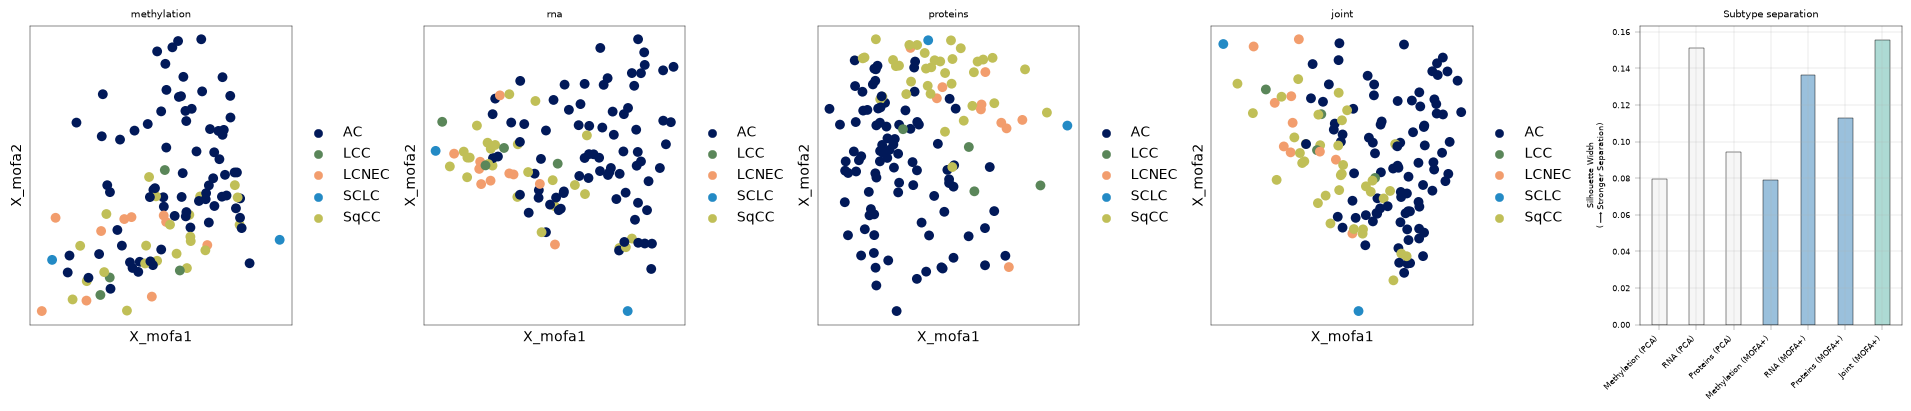

In [20]:
plot_kwargs = {
    "basis": "X_mofa",
    "color": "who2015_histology",
    "size": 200,
    "palette": apt.pl.BasePalettes().get("qualitative"),
    "show": False,
    "title": "",
}
modalities = {
    "methylation": methylation.copy(),
    "rna": rna.copy(),
    "proteins": proteins.copy(),
    "joint": multimodal.copy(),
}

fig, axm = apt.pl.create_figure(1, 5, figsize=(19, 4))

for idx, (modality, data) in enumerate(modalities.items()):
    muon.pl.embedding(data, ax=axm[idx], **plot_kwargs)
    apt.pl.label_axes(ax=axm[idx], title=modality)


apt.pl.barplot(
    ax=axm[4],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "RNA (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Proteins (PCA)": "#eeeeee",
        "Proteins (MOFA+)": apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[4],
    ylabel="Silhouette Width\n($\\longrightarrow$Stronger Separation)",
    title="Subtype separation",
)
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}

#### [Miniaturized figure for manuscript]

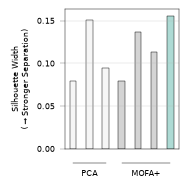

In [22]:
fig, axm = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))

# Level 2 (the omics modalities) is drawn by alphapepttools, one bar per method.
apt.pl.barplot(
    ax=axm[0],
    data=silhouette_scores,
    value_column="silhouette_width",
    grouping_column="method",
    color_dict={
        "Methylation (PCA)": "#eeeeee",
        "RNA (PCA)": "#eeeeee",
        "Proteins (PCA)": "#eeeeee",
        "Methylation (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "RNA (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "Proteins (MOFA+)": "#aaaaaa",  # apt.pl.BaseColors.get("blue"),
        "Joint (MOFA+)": apt.pl.BaseColors.get("green"),
    },
)
apt.pl.label_axes(
    ax=axm[0],
    ylabel="Silhouette Width\n($\\rightarrow$Stronger Separation)",
    # title="Subtype separation",
)
plt.xticks([])
plt.yticks([0, 0.05, 0.10, 0.15])

# Level 1 (the embedding method): PCA spans bars 0-2, MOFA+ spans bars 3-6.
annotate_level1_groups(axm[0], [("PCA", 0, 2), ("MOFA+", 3, 6)], fontweight="normal", pad=0., y=-0.1, linewidth=defaults.plot_settings.linewidths["medium"])

apt.pl.save_figure(
    fig = fig,
    filename = f"cohort_separation.png",
    output_dir = figure_output_dir,
    dpi = 600,
    transparent = True,
)

plt.show()
